# Ranking flagged journal entries: a demo on synthetic data

An audit team runs a dozen simple tests over a general ledger and gets thousands of flagged lines,
far more than anyone can review. This notebook ranks them so the review starts with the lines
most likely to matter, then checks the ranking against anomalies injected into the ledger on
purpose.

1. Generate a ledger with known anomalies.
2. Run the Python tests, and load the IDEA tests from mock exports.
3. Consolidate everything on the row ID and score it.
4. Check the priority list against the ground truth.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from glrisk import benford, evaluate, flags, pipeline, plots, rules, scoring, synthetic

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 12)

## 1. A synthetic ledger

20,000 journal lines over a year, Debit/Credit layout, with a row ID (`Sr No`) tagged first.
Normal business includes things the tests will flag anyway: round rent payments, director fees,
a supplier on fixed prices, the odd weekend posting and double postings. About 0.5% of lines are
injected anomalies, each with one to four red flags and a larger amount. They are marked in
`Anomaly`, which the tests and the scoring never read.

In [2]:
ledger = synthetic.make_ledger(20_000, seed=0)
amount_cols = synthetic.amount_columns(ledger)
print(f"{len(ledger):,} lines, {(ledger['Anomaly'] != '').sum()} injected anomalies")
ledger[ledger["Anomaly"] != ""].head()

20,050 lines, 100 injected anomalies


,Sr No,Date,Account,Description,Created By,Approved By,Debit,Credit,Anomaly
62,63,2025-01-01,Suspense Account 6,Sales invoice,user_a,manager_1,0.0,25284.89,seldom_account
142,143,2025-01-02,Suspense Account 41,Write off - settlement,user_d,manager_2,0.0,48999.00,ending_99+keyword+seldom_account
203,204,2025-01-03,Office Supplies,Utility bill,user_c,manager_1,0.0,30000.00,round_amount
224,225,2025-01-04,Accounts Payable,Supplier payment,user_b,manager_2,130000.0,0.00,round_amount+weekend
599,600,2025-01-12,Payroll Expense,Staff travel claim,user_b,manager_1,0.0,51661.80,weekend


## 2. The tests

Python runs the date, amount and keyword tests. IDEA runs Benford, the seldom account summary, the
duplicate check and segregation of duties; here its exports are the mock files in
`fixtures/idea_exports` (see `idea/README.md`). Each test becomes a set of row IDs.

In [3]:
python_flags = pipeline.run_python_tests(ledger, amount_cols)
idea_flags = flags.load_idea_flags("../fixtures/idea_exports")

pd.DataFrame({
    "Source": ["Python"] * len(python_flags) + ["IDEA"] * len(idea_flags),
    "Test": [*python_flags, *idea_flags],
    "Lines flagged": [len(v) for v in [*python_flags.values(), *idea_flags.values()]],
}).assign(**{"% of ledger": lambda t: (t["Lines flagged"] / len(ledger) * 100).round(2)})

,Source,Test,Lines flagged,% of ledger
0,Python,Suspicious Keyword,804,4.01
1,Python,Rounded Amount,242,1.21
2,Python,Ending 99/999,47,0.23
3,Python,Public Holiday,699,3.49
4,Python,Saturday,164,0.82
5,Python,Sunday,177,0.88
6,IDEA,Benford,2410,12.02
7,IDEA,Duplicate,102,0.51
8,IDEA,Seldom Account Entries,38,0.19
9,IDEA,SoD Violation Entries,46,0.23


The Benford test on the whole ledger: the fixed-price supplier pushes the digit 4 above its
expected share. The overall MAD still says the ledger conforms, which is why Benford gets a low
prior: on its own it rarely points at a problem.

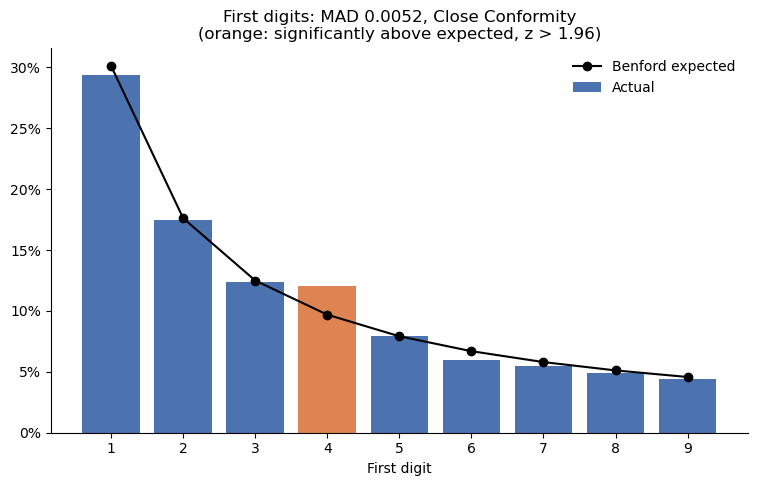

In [4]:
table = benford.first_digit_test(rules.absolute_amount(ledger, amount_cols))
plots.benford_chart(table)
plt.show()

## 3. Consolidate and score

`consolidate` gives one row per line with a column per test. The score then weights each test by
**rarity in this ledger x prior**, counts the date tests once (a Saturday that is also a public
holiday is one calendar signal, not two), scales Benford by amount diversity, and multiplies by
`1 + log10(1 + amount / median amount)`. The priors here are illustrative.

4,290 lines flagged by at least one test (21% of the ledger)


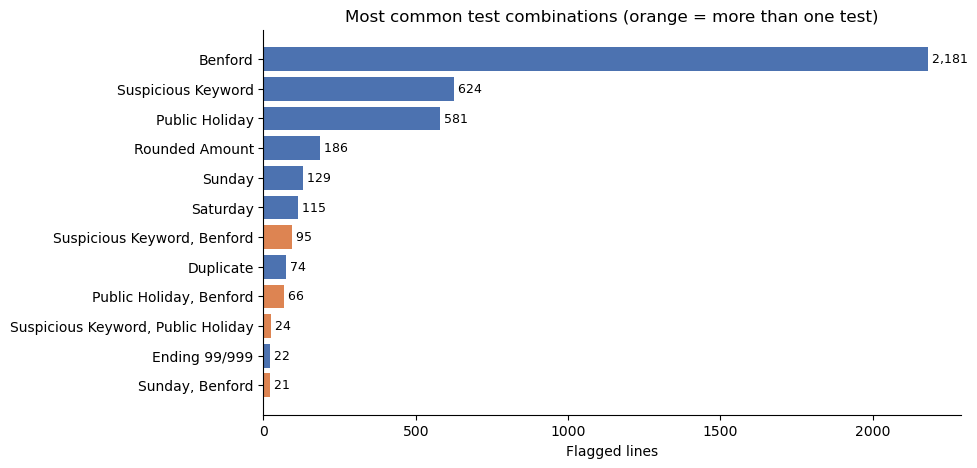

In [5]:
flagged = flags.consolidate(ledger, python_flags, idea_flags)
print(f"{len(flagged):,} lines flagged by at least one test "
      f"({len(flagged) / len(ledger):.0%} of the ledger)")
plots.flag_overlap(flagged)
plt.show()

In [6]:
scored = scoring.score_flags(flagged, amount_cols, top_n=None)
pd.Series(scored.attrs["weights"], name="Weight").sort_values(ascending=False).to_frame()

,Weight
Seldom Account Entries,6.806
Ending 99/999,3.945
Suspicious Keyword,3.492
Duplicate,3.440
Rounded Amount,2.877
SoD Violation Entries,2.639
Saturday,1.044
Sunday,1.027
Public Holiday,0.729
Benford,0.460


In [7]:
k = scoring.priority_list_size(len(ledger))
priority = scored.head(k)
print(f"Priority list: {k} lines (0.577 x sqrt({len(ledger):,}), within 20-150)")
priority[["Sr No", "Date", "Account", "Description", *amount_cols, "Score"]].head(10)

Priority list: 82 lines (0.577 x sqrt(20,050), within 20-150)


,Sr No,Date,Account,Description,Debit,Credit,Score
12950,12951,2025-08-26,Suspense Account 14,Write off - settlement,130000.0,0.0,39.820
16354,16355,2025-10-25,Suspense Account 25,"Cash advance, no invoice",130000.0,0.0,35.803
14019,14020,2025-09-14,Suspense Account 3,Consultancy fee (related party),75999.0,0.0,35.029
4025,4026,2025-03-15,Suspense Account 21,Utility bill,150000.0,0.0,34.458
3647,3648,2025-03-08,Suspense Account 37,Adjustment per director,0.0,54999.0,33.050
13208,13209,2025-08-29,Suspense Account 48,"Cash advance, no invoice",0.0,77999.0,32.830
6018,6019,2025-04-23,Suspense Account 36,Purchase invoice,0.0,170000.0,32.419
14085,14086,2025-09-15,Suspense Account 45,Adjustment per director,0.0,63999.0,31.676
12317,12318,2025-08-14,Suspense Account 1,"Cash advance, no invoice",24999.0,0.0,31.299
1803,1804,2025-02-01,Suspense Account 33,Supplier payment,54999.0,0.0,31.206


Each line carries its own explanation: the weight of every test it hit (date tests as one
term), times the amount multiplier. A reviewer can see why a line is where it is, and challenge it.

In [8]:
with pd.option_context("display.max_colwidth", None):
    display(priority[["Sr No", "Score", "Score Breakdown"]].head(5))

,Sr No,Score,Score Breakdown
12950,12951,39.820,"Seldom Account Entries 6.8 + Suspicious Keyword 3.5 + Rounded Amount 2.9 + SoD Violation Entries 2.6, × amount 2.52"
16354,16355,35.803,"Seldom Account Entries 6.8 + Suspicious Keyword 3.5 + Rounded Amount 2.9 + date (Saturday) 1.0, × amount 2.52"
14019,14020,35.029,"Seldom Account Entries 6.8 + Ending 99/999 3.9 + Suspicious Keyword 3.5 + date (Sunday) 1.0, × amount 2.29"
4025,4026,34.458,"Seldom Account Entries 6.8 + Rounded Amount 2.9 + SoD Violation Entries 2.6 + date (Saturday) 1.0, × amount 2.58"
3647,3648,33.050,"Seldom Account Entries 6.8 + Ending 99/999 3.9 + Suspicious Keyword 3.5 + date (Saturday) 1.0, × amount 2.16"


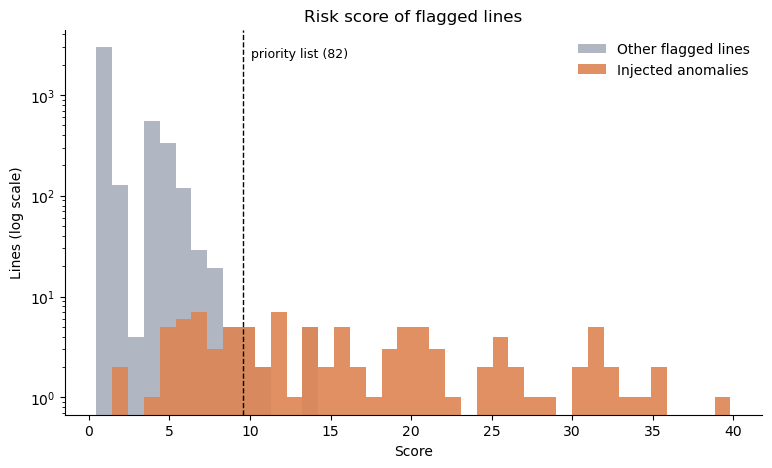

In [9]:
plots.score_distribution(scored, k)
plt.show()

## 4. Does the ranking find the injected anomalies?

Precision@k is the share of the priority list that are injected anomalies; recall@k is the share
of all anomalies that made the list. The baselines: the number of tests hit (a common manual
approach), an Isolation Forest on simple line features, amount alone, and a random order of the
flagged lines. The ceiling is the best any ranking of the flagged lines could do.

This is one seed, as a worked example; `docs/benchmark_results.md` has the mean and spread over 30
seeds, the ablation study and the sweeps.

In [10]:
results = evaluate.compare_rankings(scored, ledger, amount_cols, k, ml=True)
results

,Precision@82,Recall@82
Risk score,0.854,0.70
Number of tests hit,0.756,0.62
Amount only,0.329,0.27
Random flagged lines,0.012,0.01
Isolation Forest,0.695,0.57
Ceiling (flagged lines),1.000,1.00


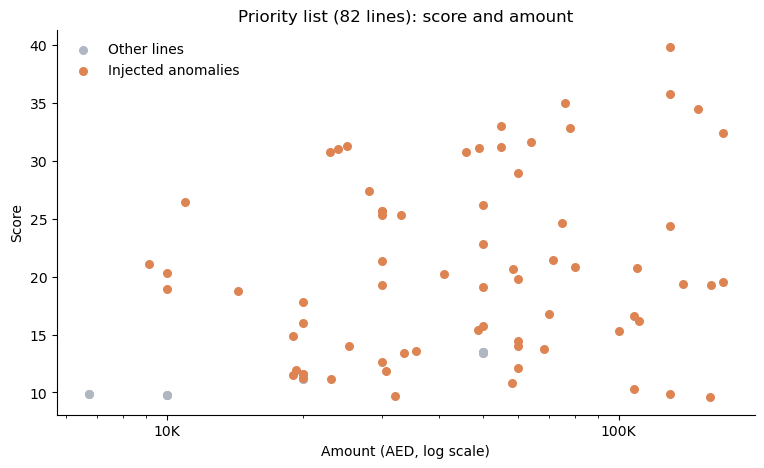

In [11]:
plots.priority_amounts(priority, amount_cols)
plt.show()

Counting tests treats a weekend posting the same as a posting to an account used twice a year.
Weighting by rarity separates them, and the amount multiplier lifts large entries with a single
rare flag, which a count of tests misses. On this ledger the risk score's priority list is more
precise than counting tests, the Isolation Forest and amount alone.

The anomalies come from the same generator the scoring was designed around, so these numbers
show the method works as intended. They are not a claim about real ledgers.